In [21]:
import numpy as np
np.set_printoptions(legacy='1.25')

import math
import matplotlib.pyplot as plt
from numba import njit

In [7]:
def energy(s, J, h):
    #2D Ising energy with periodic boundary conditions.
    
    E = 0.0
    N = s.shape[0]

    for i in range(N):
        for j in range(N):
            E -= J * s[i, j] * (
                s[(i + 1) % N, j] +
                s[i, (j + 1) % N]
            )
            E -= h * s[i, j]

    return E

@njit
def sweep_once(s, N, J, h, T, E):
    for _ in range(N * N):
        x = np.random.randint(N)
        y = np.random.randint(N)

        nn = (
            s[(x + 1) % N, y] +
            s[(x - 1) % N, y] +
            s[x, (y + 1) % N] +
            s[x, (y - 1) % N]
        )

        dE = 2 * s[x, y] * (J * nn + h)

        if dE <= 0 or np.random.rand() < math.exp(-dE / T):
            s[x, y] *= -1
            E += dE

    return E

In [8]:
def sim_annealing_ising(N,J,h,Tstart,Tend,alpha,sweeps_per_T):
    
    s = np.random.choice(np.array([-1, 1]), size=(N, N))

    E = energy(s, J, h)
    
    temps=[]
    energies=[]
    mags =[]
    
    T=Tstart
    
    while T > Tend:
        
        for _ in range(sweeps_per_T):
            E = sweep_once(s, N, J, h, T, E)
            
        temps.append(T)
        energies.append(E)
        mags.append(s.sum())
        
        T *= alpha
    
    return np.array(temps), np.array(energies), np.array(mags) , s.copy()


In [11]:
temps, energies, mags, final_state = sim_annealing_ising(
    N=50,
    J=5,
    h=0,
    Tstart=15,
    Tend=5,
    alpha=0.99,
    sweeps_per_T=1000
)

print("Temps")
print(temps)
print("           ")
print("Energies")
print(energies)
print("           ")

print("magentisation")
print(mags)
print("           ")

print("the final state")
print(final_state)

Temps
[15.         14.85       14.7015     14.554485   14.40894015 14.26485075
 14.12220224 13.98098022 13.84117042 13.70275871 13.56573113 13.43007381
 13.29577308 13.16281534 13.03118719 12.90087532 12.77186657 12.6441479
 12.51770642 12.39252936 12.26860406 12.14591802 12.02445884 11.90421425
 11.78517211 11.66732039 11.55064719 11.43514072 11.32078931 11.20758141
 11.0955056  10.98455054 10.87470504 10.76595799 10.65829841 10.55171542
 10.44619827 10.34173629 10.23831893 10.13593574 10.03457638  9.93423061
  9.83488831  9.73653943  9.63917403  9.54278229  9.44735447  9.35288092
  9.25935211  9.16675859  9.07509101  8.9843401   8.8944967   8.80555173
  8.71749621  8.63032125  8.54401804  8.45857786  8.37399208  8.29025216
  8.20734964  8.12527614  8.04402338  7.96358314  7.88394731  7.80510784
  7.72705676  7.64978619  7.57328833  7.49755545  7.42257989  7.3483541
  7.27487055  7.20212185  7.13010063  7.05879962  6.98821163  6.91832951
  6.84914622  6.78065475  6.71284821  6.6457197

In [40]:
speeds =  np.linspace(.4 , .99 , 100)

#speeds = [0.5,0.75,0.8, 0.9, 0.95,0.96,0.97,0.98, 0.99]

ground_E=[]

for a in speeds:
    temps, energies, mags, final_state = sim_annealing_ising(
    N=50,
    J=5,
    h=0,
    Tstart=20,
    Tend=5,
    alpha=a,
    sweeps_per_T=100)
    
    ground_E.append(energies[-1])
    


print(f"speeds {speeds}")
print("gsE")
print(ground_E)

speeds [0.4        0.4059596  0.41191919 0.41787879 0.42383838 0.42979798
 0.43575758 0.44171717 0.44767677 0.45363636 0.45959596 0.46555556
 0.47151515 0.47747475 0.48343434 0.48939394 0.49535354 0.50131313
 0.50727273 0.51323232 0.51919192 0.52515152 0.53111111 0.53707071
 0.5430303  0.5489899  0.55494949 0.56090909 0.56686869 0.57282828
 0.57878788 0.58474747 0.59070707 0.59666667 0.60262626 0.60858586
 0.61454545 0.62050505 0.62646465 0.63242424 0.63838384 0.64434343
 0.65030303 0.65626263 0.66222222 0.66818182 0.67414141 0.68010101
 0.68606061 0.6920202  0.6979798  0.70393939 0.70989899 0.71585859
 0.72181818 0.72777778 0.73373737 0.73969697 0.74565657 0.75161616
 0.75757576 0.76353535 0.76949495 0.77545455 0.78141414 0.78737374
 0.79333333 0.79929293 0.80525253 0.81121212 0.81717172 0.82313131
 0.82909091 0.83505051 0.8410101  0.8469697  0.85292929 0.85888889
 0.86484848 0.87080808 0.87676768 0.88272727 0.88868687 0.89464646
 0.90060606 0.90656566 0.91252525 0.91848485 0.92444444

/tmp/ipykernel_3003/2749984821.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


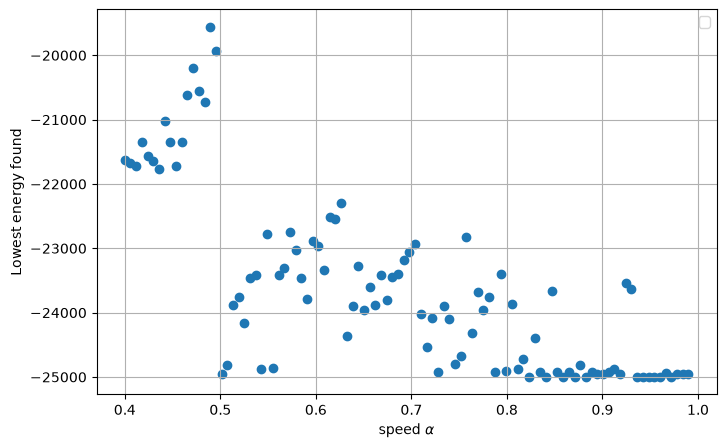

In [41]:
plt.figure(figsize=(8,5))


plt.scatter(speeds,ground_E)
plt.xlabel(r"speed $\alpha$")
plt.ylabel(r"Lowest energy found")
#plt.title("")
plt.grid(True)
plt.legend()

plt.show()